# 3 Maneras de Programar a una Red Neuronal - DOTCSV
Modificaciones 2026: Elizabeth Sena

## Código inicial

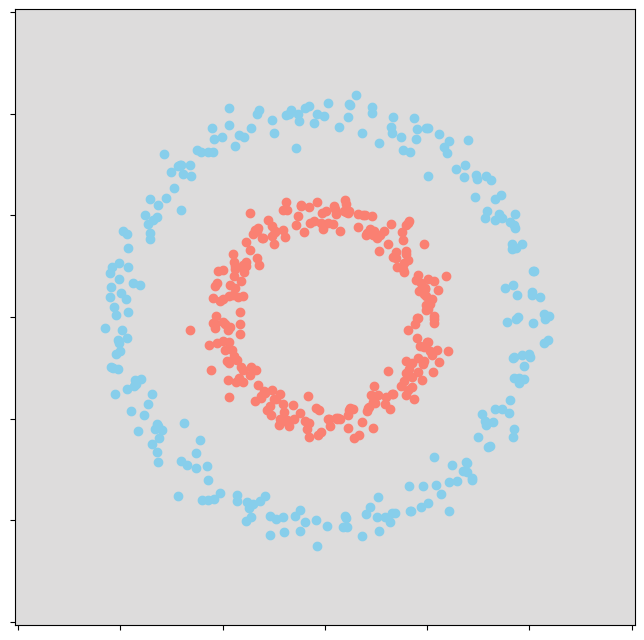

In [4]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles

# Creamos nuestros datos artificiales, donde buscaremos clasificar
# dos anillos concéntricos de datos.
X, Y = make_circles(n_samples=500, factor=0.5, noise=0.05)

# Resolución del mapa de predicción.
res = 100

# Coordendadas del mapa de predicción.
_x0 = np.linspace(-1.5, 1.5, res)
_x1 = np.linspace(-1.5, 1.5, res)

# Input con cada combo de coordenadas del mapa de predicción.
_pX = np.array(np.meshgrid(_x0, _x1)).T.reshape(-1, 2)

# Objeto vacio a 0.5 del mapa de predicción.
_pY = np.zeros((res, res)) + 0.5

# Visualización del mapa de predicción.
plt.figure(figsize=(8, 8))
plt.pcolormesh(_x0, _x1, _pY, cmap="coolwarm", vmin=0, vmax=1)

# Visualización de la nube de datos.
plt.scatter(X[Y == 0,0], X[Y == 0,1], c="skyblue")
plt.scatter(X[Y == 1,0], X[Y == 1,1], c="salmon")

plt.tick_params(labelbottom=False, labelleft=False)

## Tensorflow

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import display, HTML

lr = 0.05
nn = [2, 16, 8, 1]

# Variables (weights/biases)
W1 = tf.Variable(tf.random.normal([nn[0], nn[1]]))
b1 = tf.Variable(tf.random.normal([nn[1]]))
W2 = tf.Variable(tf.random.normal([nn[1], nn[2]]))
b2 = tf.Variable(tf.random.normal([nn[2]]))
W3 = tf.Variable(tf.random.normal([nn[2], nn[3]]))
b3 = tf.Variable(tf.random.normal([nn[3]]))

def forward(x):
    l1 = tf.nn.relu(tf.matmul(x, W1) + b1)
    l2 = tf.nn.relu(tf.matmul(l1, W2) + b2)
    out = tf.nn.sigmoid(tf.matmul(l2, W3) + b3)[:, 0]
    return out

optimizer = tf.optimizers.SGD(learning_rate=lr)

X_tf = tf.constant(X, dtype=tf.float32)
Y_tf = tf.constant(Y, dtype=tf.float32)

n_steps = 1000
iPY = []

for step in range(n_steps):
    with tf.GradientTape() as tape:
        pY = forward(X_tf)
        loss = tf.reduce_mean(tf.square(pY - Y_tf))  # equivalent to MSE

    grads = tape.gradient(loss, [W1, b1, W2, b2, W3, b3])
    optimizer.apply_gradients(zip(grads, [W1, b1, W2, b2, W3, b3]))

    if step % 25 == 0:
        acc = np.mean(np.round(pY.numpy()) == Y)
        print('Step', step, '/', n_steps, '- Loss =', loss.numpy(), '- Acc =', acc)

        _pY = forward(tf.constant(_pX, dtype=tf.float32)).numpy().reshape((res, res))
        iPY.append(_pY)

Step 0 / 1000 - Loss = 0.5286511 - Acc = 0.448
Step 25 / 1000 - Loss = 0.5164288 - Acc = 0.46
Step 50 / 1000 - Loss = 0.5071143 - Acc = 0.472
Step 75 / 1000 - Loss = 0.49958307 - Acc = 0.48
Step 100 / 1000 - Loss = 0.49335113 - Acc = 0.49
Step 125 / 1000 - Loss = 0.48549667 - Acc = 0.49
Step 150 / 1000 - Loss = 0.47030813 - Acc = 0.512
Step 175 / 1000 - Loss = 0.45773423 - Acc = 0.518
Step 200 / 1000 - Loss = 0.451126 - Acc = 0.526
Step 225 / 1000 - Loss = 0.44288248 - Acc = 0.536
Step 250 / 1000 - Loss = 0.42883348 - Acc = 0.532
Step 275 / 1000 - Loss = 0.40956712 - Acc = 0.556
Step 300 / 1000 - Loss = 0.38783002 - Acc = 0.582
Step 325 / 1000 - Loss = 0.3188378 - Acc = 0.604
Step 350 / 1000 - Loss = 0.2509214 - Acc = 0.724
Step 375 / 1000 - Loss = 0.20821273 - Acc = 0.788
Step 400 / 1000 - Loss = 0.18630673 - Acc = 0.818
Step 425 / 1000 - Loss = 0.17552443 - Acc = 0.83
Step 450 / 1000 - Loss = 0.1693556 - Acc = 0.84
Step 475 / 1000 - Loss = 0.16449146 - Acc = 0.844
Step 500 / 1000 - L

## Keras

In [10]:
import tensorflow as tf
import tensorflow.keras as kr
import matplotlib.pyplot as plt

from IPython.display import display, HTML


lr = 0.01           # learning rate
nn = [2, 16, 8, 1]  # número de neuronas por capa.


# Creamos el objeto que contendrá a nuestra red neuronal, como
# secuencia de capas.
model = kr.Sequential()

# Añadimos la capa 1. input_shape=(2,) porque cada dato de entrada tiene 2 coordenadas (x0, x1).
model.add(kr.layers.Dense(nn[1], activation='relu', input_shape=(2,)))
# Dropout: Apagamos aleatoriamente el 20% de las neuronas en cada paso
#model.add(kr.layers.Dropout(0.2))

# Añadimos la capa 2
model.add(kr.layers.Dense(nn[2], activation='relu'))

# Añadimos la capa 3
model.add(kr.layers.Dense(nn[3], activation='sigmoid'))

# Compilamos el modelo, definiendo la función de coste y el optimizador.
model.compile(loss='mse', optimizer=kr.optimizers.SGD(learning_rate=0.05), metrics=['acc'])

# Entrenamos SIN ningún control de sobreajuste (baseline), reservando un 20%
# de los datos como validación para poder comparar train vs val.
historial_base = model.fit(X, Y, epochs=100, validation_split=0.2, verbose=0)

# Visualizamos: si "Validación" empieza a subir mientras "Entrenamiento" sigue
# bajando, es la señal clásica de sobreajuste (overfitting).
plt.plot(historial_base.history['loss'], label='Entrenamiento (Loss)')
plt.plot(historial_base.history['val_loss'], label='Validación (Val Loss)')
plt.xlabel('Epochs')
plt.ylabel('Error (MSE)')
plt.title('Baseline sin control de sobreajuste')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.5040 - loss: 0.2584   
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.4780 - loss: 0.2569 
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.4700 - loss: 0.2555 
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.4720 - loss: 0.2543 
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.4680 - loss: 0.2532 
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.4120 - loss: 0.2522 
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.4100 - loss: 0.2515 
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.4300 - loss: 0.2505 
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.4580 - loss: 0.2497 
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.4520 - loss: 0.2487 
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.4880 - loss: 0.2476 
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.4940 - loss: 0.2465 
Epoch 13/100
16/16 ━━━━

### Ahora vamos a corregirlo
Si en la gráfica anterior ves que la línea de validación se separa de la de entrenamiento, el modelo está memorizando en vez de aprender. Vamos a añadir herramientas para evitarlo.

In [14]:
#Prevención sobreajuste de Keras

import tensorflow.keras as kr

# 1. Reconstruimos el modelo DESDE CERO (importante: si reutilizáramos el
#    "model" de la celda anterior, ya vendría parcialmente entrenado y
#    los resultados no serían comparables).
model = kr.Sequential()
model.add(kr.layers.Dense(16, activation='relu', input_shape=(2,)))
model.add(kr.layers.Dense(8, activation='relu'))
model.add(kr.layers.Dense(1, activation='sigmoid'))

model.compile(loss='mse', optimizer=kr.optimizers.SGD(learning_rate=0.05), metrics=['acc'])

# 2. Definimos el "asistente" de Parada Temprana
early_stopping = kr.callbacks.EarlyStopping(
    monitor='val_loss',         # Métrica a vigilar: el error en el examen de validación
    patience=10,                # Tolerancia: 10 epochs sin mejorar antes de parar
    restore_best_weights=True   # Recupera la mejor versión de los pesos al terminar
)

# 3. Entrenamos el modelo añadiendo validación y callbacks
print("Iniciando entrenamiento con Validación y Early Stopping...")
historial = model.fit(
    X, Y,
    epochs=100,
    validation_split=0.2,       # Reserva el 20% de los datos en secreto para validar
    callbacks=[early_stopping], # Activa las alarmas automáticas
    verbose=1
)


Iniciando entrenamiento con Validación y Early Stopping...
Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 1.0000 - loss: 0.0260 - val_acc: 1.0000 - val_loss: 0.0283
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 1.0000 - loss: 0.0252 - val_acc: 1.0000 - val_loss: 0.0276
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 1.0000 - loss: 0.0244 - val_acc: 1.0000 - val_loss: 0.0269
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 1.0000 - loss: 0.0237 - val_acc: 1.0000 - val_loss: 0.0262
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 1.0000 - loss: 0.0230 - val_acc: 1.0000 - val_loss: 0.0256
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 1.0000 - loss: 0.0223 - val_acc: 1.0000 - val_loss: 0.0248
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 1.0000 - loss: 0.0217 - val_acc: 1.0000 - val_loss: 0.0242
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 1.0000 - loss: 0.0210 - val_acc: 1.0000 - val_loss: 0.0237
Epoc

Iniciando entrenamiento desde cero...


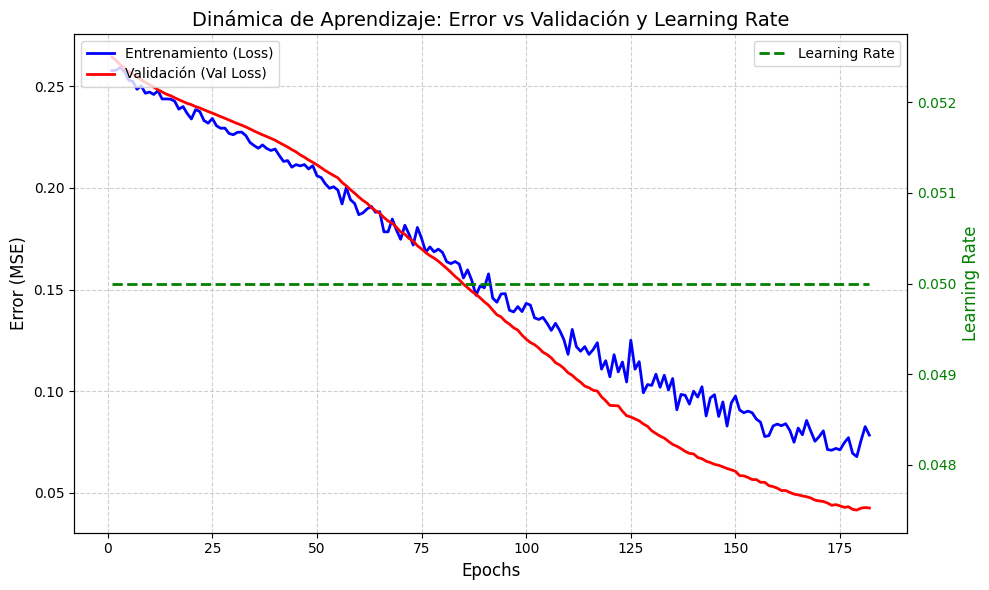

In [21]:
import matplotlib.pyplot as plt
import tensorflow.keras as kr

# ==========================================
# 1. CREACIÓN DEL MODELO (Aquí nace "model")
# ==========================================
model = kr.Sequential()
model.add(kr.layers.Dense(16, activation='relu', input_shape=(2,)))
model.add(kr.layers.Dropout(0.2))
model.add(kr.layers.Dense(8, activation='relu'))
model.add(kr.layers.Dropout(0.2))
model.add(kr.layers.Dense(1, activation='sigmoid'))

model.compile(loss='mse', optimizer=kr.optimizers.SGD(learning_rate=0.05), metrics=['acc'])

# ==========================================
# 2. DEFINICIÓN DE CALLBACKS
# ==========================================
early_stopping = kr.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = kr.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.0001
)

# ==========================================
# 3. ENTRENAMIENTO
# ==========================================
print("Iniciando entrenamiento desde cero...")
historial = model.fit(
    X, Y,
    epochs=500,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)

# ==========================================
# 4. GRÁFICA DE DINÁMICA DE APRENDIZAJE
# ==========================================
loss = historial.history['loss']
val_loss = historial.history['val_loss']
lr = historial.history['learning_rate']
epochs = range(1, len(loss) + 1)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(epochs, loss, 'b-', label='Entrenamiento (Loss)', linewidth=2)
ax1.plot(epochs, val_loss, 'r-', label='Validación (Val Loss)', linewidth=2)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Error (MSE)', color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(epochs, lr, 'g--', label='Learning Rate', linewidth=2)
ax2.set_ylabel('Learning Rate', color='green', fontsize=12)
ax2.tick_params(axis='y', labelcolor='green')
ax2.legend(loc='upper right')

plt.title('Dinámica de Aprendizaje: Error vs Validación y Learning Rate', fontsize=14)
fig.tight_layout()
plt.show()

## Sklearn

In [15]:
import sklearn as sk
import sklearn.neural_network

from IPython.display import display, HTML


lr = 0.01           # learning rate
nn = [2, 16, 8, 1]  # número de neuronas por capa.

# Usamos MLPClassifier (no MLPRegressor) porque Y es una etiqueta binaria
# (0 o 1, a qué anillo pertenece cada punto), no un valor continuo.
clf = sk.neural_network.MLPClassifier(solver='sgd',
                                     learning_rate_init=lr,
                                     hidden_layer_sizes=tuple(nn[1:-1]),  # sklearn añade la capa de salida solo
                                     verbose=True,
                                     max_iter=1000,
                                     n_iter_no_change=1000,
                                     batch_size=64)


# Y lo entrenamos con nuestros datos.
clf.fit(X, Y)

print("Precisión final:", clf.score(X, Y))


Iteration 1, loss = 0.12906291
Iteration 2, loss = 0.12452744
Iteration 3, loss = 0.11956857
Iteration 4, loss = 0.11153443
Iteration 5, loss = 0.10671902
Iteration 6, loss = 0.10275731
Iteration 7, loss = 0.09915047
Iteration 8, loss = 0.09522346
Iteration 9, loss = 0.09132441
Iteration 10, loss = 0.08796164
Iteration 11, loss = 0.08477433
Iteration 12, loss = 0.08185812
Iteration 13, loss = 0.07854080
Iteration 14, loss = 0.07555480
Iteration 15, loss = 0.07269671
Iteration 16, loss = 0.06973969
Iteration 17, loss = 0.06652034
Iteration 18, loss = 0.06342435
Iteration 19, loss = 0.06040466
Iteration 20, loss = 0.05750650
Iteration 21, loss = 0.05413737
Iteration 22, loss = 0.05044122
Iteration 23, loss = 0.04678090
Iteration 24, loss = 0.04273556
Iteration 25, loss = 0.03893849
Iteration 26, loss = 0.03512041
Iteration 27, loss = 0.03094442
Iteration 28, loss = 0.02727725
Iteration 29, loss = 0.02414180
Iteration 30, loss = 0.02107648
Iteration 31, loss = 0.01849970
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(batch_size=64, hidden_layer_sizes=(16, 8, 1),
             learning_rate_init=0.01, max_iter=1000, n_iter_no_change=1000,
             solver='sgd', verbose=True)